In [62]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn import svm

In [22]:
loan_dataset = pd.read_csv('/content/loan_dataset.csv')

In [23]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [26]:
# # LABEL ENCODING

# manul aproch
# loan_dataset=loan_dataset.replace({'Loan_Status':{'N':0,'Y':1}},inplace=True)

#using label encoding approch
label_encoder = LabelEncoder()

# Apply label encoding to the 'Loan_Status' column
loan_dataset['Loan_Status'] = label_encoder.fit_transform(loan_dataset['Loan_Status'])


# loan_dataset.head()

In [27]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [31]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,0.687296
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.463973
min,150.000000,0.000000,9.000000,12.00000,0.000000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,0.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000


In [34]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [38]:
#handling missing DATA
loan_dataset=loan_dataset.dropna()

In [39]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [41]:
#analysing all features
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [42]:
loan_dataset=loan_dataset.replace(to_replace='3+',value=4)

In [45]:
loan_dataset['Property_Area'].value_counts()


,count
Property_Area,
Semiurban,191
Urban,150
Rural,139


DATA VISULIZATION

<Axes: xlabel='Education', ylabel='count'>

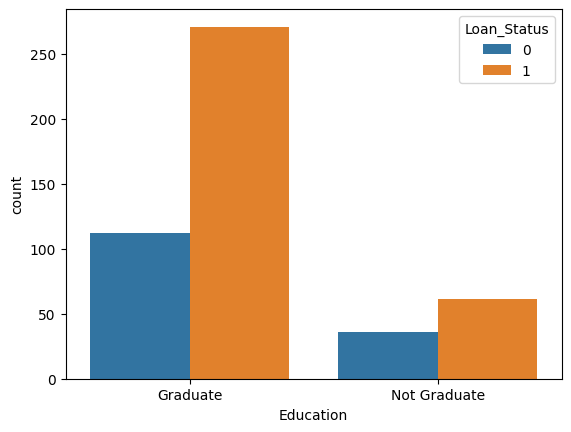

In [55]:
sns.countplot(x='Education',hue='Loan_Status',data=loan_dataset)

In [56]:
loan_dataset['Gender'] = label_encoder.fit_transform(loan_dataset['Gender'])
loan_dataset['Married'] = label_encoder.fit_transform(loan_dataset['Married'])
loan_dataset['Education'] = label_encoder.fit_transform(loan_dataset['Education'])
loan_dataset['Self_Employed'] = label_encoder.fit_transform(loan_dataset['Self_Employed'])
loan_dataset['Property_Area'] = label_encoder.fit_transform(loan_dataset['Property_Area'])


In [57]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1


In [59]:
#sapparating the taget and featurs
X=loan_dataset.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y=loan_dataset['Loan_Status']

In [60]:
print(X)
print(Y)

     Gender  Married Dependents  ...  Loan_Amount_Term  Credit_History  Property_Area
1         1        1          1  ...             360.0             1.0              0
2         1        1          0  ...             360.0             1.0              2
3         1        1          0  ...             360.0             1.0              2
4         1        0          0  ...             360.0             1.0              2
5         1        1          2  ...             360.0             1.0              2
..      ...      ...        ...  ...               ...             ...            ...
609       0        0          0  ...             360.0             1.0              0
610       1        1          4  ...             180.0             1.0              0
611       1        1          1  ...             360.0             1.0              2
612       1        1          2  ...             360.0             1.0              2
613       0        0          0  ...             360.0

#splitting the data


In [61]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
print(X_train.shape,X.shape)

(384, 11) (480, 11)


## TRANING*

In [63]:
classifier = svm.SVC(kernel='linear')

In [64]:
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

In [65]:
# accuracy score on training data
X_train_prediction = classifier.predict(X_train)
training_data_accuray = accuracy_score(X_train_prediction,Y_train)
print('Accuracy on training data : ', training_data_accuray)


# accuracy score on training data
X_test_prediction = classifier.predict(X_test)
test_data_accuray = accuracy_score(X_test_prediction,Y_test)
print('Accuracy on test data : ', test_data_accuray)

Accuracy on training data :  0.8020833333333334
Accuracy on test data :  0.8229166666666666


In [ ]:
# predictive system